# Model Comparison: EOFlow vs scVI vs scGen vs Means

Loads all four trained models against the same held-out `key` condition and lines up ROC, MMD, mean-expression, effect-size, and violin-plot diagnostics into 2x2 grids so they can be compared directly.

## 0. Imports

In [1]:
import os
import torch
import matplotlib.pyplot as plt

import scgen

from src.model.VAE.VAE_model import MixturePriorSCVI, SCVIMixturePriorWrapper
from src.model.SCGEN.SCGEN_model import SCGENMixturePriorWrapper
from src.model.Mean.Mean_model import MeanShifter
from src.model.data_utils import load_data

from src.analysis.analysis_utils import Analyzer, get_model_from_checkpoint
from src.analysis.logistic_regression import (
    generate_counterfactuals,
    generate_counterfactuals_scvi,
    generate_counterfactuals_scgen,
    generate_counterfactuals_mean,
    evaluate_cf_roc,
)
from src.analysis.mmd import ctrl_mmd_dists, mmd_dists, plot_mmd_dists
from src.analysis.cf_expressions import (
    plot_mean_expression_comparison,
    plot_effect_size_comparison,
    plot_top_deg_violin,
)

## 1. Config

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
key = "CT-1"

comparison_dir = "/home/jhoefer/sandbox/results/comparison"
plot_dir = os.path.join(comparison_dir, "plots")
os.makedirs(plot_dir, exist_ok=True)

## 2. Load Models

### 2.1 EOFlow

In [3]:
eoflow_dataset_args = {
    "dataset_name": "parse",
    "top_genes": 2000,
    "sigma_noise": 0.1,
    "lam_MTC": 0.3,
    "use_counts": False,
}
eoflow_prefix = ""

eoflow_adata, eoflow_labels_key, eoflow_control_label = load_data(
    eoflow_dataset_args["dataset_name"],
    eoflow_dataset_args["top_genes"],
    log_transform=True,
    cell_types=["CD4 Memory"],
)

eoflow_dataset_name = eoflow_dataset_args["dataset_name"]
eoflow_top_genes = min(eoflow_dataset_args["top_genes"], eoflow_adata.shape[1])
eoflow_sigma_noise = eoflow_dataset_args["sigma_noise"]
eoflow_lam_MTC = eoflow_dataset_args["lam_MTC"]

eoflow_model_path = os.path.join(
    "/g/stegle/jhoefer/models/EOFlow", eoflow_dataset_name, "top_" + str(eoflow_top_genes)
)
eoflow_model_name = (
    eoflow_prefix
    + "MTC_"
    + str(eoflow_lam_MTC)
    + "_sigma_"
    + str(eoflow_sigma_noise)
    + "_model.pt"
)

eoflow_output_dir_path = os.path.join(
    "/home/jhoefer/sandbox/results", eoflow_dataset_name, "top_" + str(eoflow_top_genes)
)
eoflow_output_dir_name = (
    eoflow_prefix + "MTC_" + str(eoflow_lam_MTC) + "_sigma_" + str(eoflow_sigma_noise)
)

if eoflow_dataset_args["use_counts"]:
    eoflow_model_path += "_counts"
    eoflow_output_dir_path += "_counts"

eoflow_model_path += "_best"
eoflow_output_dir_path += "_best"

eoflow_plot_dir = os.path.join(eoflow_output_dir_path, "plots", eoflow_output_dir_name)
eoflow_csv_dir = os.path.join(eoflow_output_dir_path, "csv", eoflow_output_dir_name)
os.makedirs(eoflow_plot_dir, exist_ok=True)
os.makedirs(eoflow_csv_dir, exist_ok=True)

eoflow_checkpoint_path = os.path.join(eoflow_model_path, eoflow_model_name)

eoflow_model, _, eoflow_metrics_loss, eoflow_val_metrics_loss, eoflow_model_config = (
    get_model_from_checkpoint(eoflow_checkpoint_path, device)
)

eoflow_analyzer = Analyzer(
    eoflow_adata,
    eoflow_model,
    {"device": device, "dtype": dtype, "sigma_noise": 0.0},
    eoflow_labels_key,
    eoflow_control_label,
    eoflow_plot_dir,
    eoflow_csv_dir,
    checkpoint_path=eoflow_checkpoint_path,
    metrics_loss=eoflow_metrics_loss,
    conditions=[eoflow_labels_key],
    condition_type=eoflow_model_config.condition_type,
    val_metrics_loss=eoflow_val_metrics_loss,
)

Loaded successfully. Missing/fresh keys: []
Checkpoint found at epoch 939.


### 2.2 scVI

In [4]:
scvi_beta = 0.01
scvi_lr_means = 1e-5
scvi_model_path = "/g/stegle/jhoefer/models/cvae"

scvi_adata, scvi_labels_key, scvi_control_label = load_data(
    "parse", 2000, log_transform=False, cell_types=["CD4 Memory"],
)
scvi_adata.obs["cluster_idx"] = scvi_adata.obs[scvi_labels_key].astype("category").cat.codes

scvi_model = MixturePriorSCVI.load(
    scvi_model_path, adata=scvi_adata, prefix=f"{scvi_beta}_beta_{scvi_lr_means}_lr_means_"
)
scvi_wrapper = SCVIMixturePriorWrapper(scvi_model).to(device)

scvi_analyzer = Analyzer(
    scvi_adata,
    scvi_wrapper,
    {"device": device, "dtype": dtype, "sigma_noise": 0.0},
    scvi_labels_key,
    scvi_control_label,
    os.path.join(comparison_dir, "scvi", "plots"),
    os.path.join(comparison_dir, "scvi", "csv"),
    checkpoint_path=scvi_model_path,
    conditions=[scvi_labels_key],
    condition_type="mixture",
)
os.makedirs(scvi_analyzer.plot_dir, exist_ok=True)
os.makedirs(scvi_analyzer.csv_dir, exist_ok=True)

INFO     File /g/stegle/jhoefer/models/cvae/0.01_beta_1e-05_lr_means_model.pt already downloaded                   


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jhoefer/sandbox/.venv/lib/python3.11/site-pack ...


### 2.3 scGen

In [5]:
scgen_model_path = "/g/stegle/jhoefer/models/scgen"

scgen_adata, scgen_labels_key, scgen_control_label = load_data(
    "parse", 2000, log_transform=False, cell_types=["CD4 Memory"],
)

scgen_model = scgen.SCGEN.load(os.path.join(scgen_model_path, "model.pt"), adata=scgen_adata)
scgen_wrapper = SCGENMixturePriorWrapper(scgen_model, scgen_adata, scgen_labels_key)

scgen_analyzer = Analyzer(
    scgen_adata,
    scgen_wrapper,
    {"device": device, "dtype": dtype, "sigma_noise": 0.0},
    scgen_labels_key,
    scgen_control_label,
    os.path.join(comparison_dir, "scgen", "plots"),
    os.path.join(comparison_dir, "scgen", "csv"),
    checkpoint_path=None,
    conditions=[scgen_labels_key],
    condition_type=None,
)
os.makedirs(scgen_analyzer.plot_dir, exist_ok=True)
os.makedirs(scgen_analyzer.csv_dir, exist_ok=True)

INFO     File /g/stegle/jhoefer/models/scgen/model.pt/model.pt already downloaded                                  


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jhoefer/sandbox/.venv/lib/python3.11/site-pack ...


### 2.4 Means

In [6]:
mean_adata, mean_labels_key, mean_control_label = load_data(
    "parse", 2000, log_transform=True, cell_types=["CD4 Memory"],
)

MeanShifter.setup_anndata(mean_adata, mean_labels_key, mean_control_label)
mean_shifter = MeanShifter(mean_adata)
mean_shifter.train()

mean_analyzer = Analyzer(
    mean_adata,
    mean_shifter,
    {"device": device, "dtype": dtype, "sigma_noise": 0.0},
    mean_labels_key,
    mean_control_label,
    os.path.join(comparison_dir, "mean", "plots"),
    os.path.join(comparison_dir, "mean", "csv"),
    checkpoint_path=None,
)
os.makedirs(mean_analyzer.plot_dir, exist_ok=True)
os.makedirs(mean_analyzer.csv_dir, exist_ok=True)

### 2.5 Registry

In [7]:
models = [
    {
        "name": "EOFlow",
        "analyzer": eoflow_analyzer,
        "cf_fn": generate_counterfactuals,
        "log1p_transform": False,
    },
    {
        "name": "scVI",
        "analyzer": scvi_analyzer,
        "cf_fn": generate_counterfactuals_scvi,
        "log1p_transform": True,
    },
    {
        "name": "scGen",
        "analyzer": scgen_analyzer,
        "cf_fn": generate_counterfactuals_scgen,
        "log1p_transform": True,
    },
    {
        "name": "Means",
        "analyzer": mean_analyzer,
        "cf_fn": generate_counterfactuals_mean,
        "log1p_transform": False,
    },
]

## 3. Comparison Plots

### 3.1 ROC Curves

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:08<00:00,  1.23it/s]


Best Validation Accuracy: 0.9646
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:08<00:00,  1.19it/s]


Best Validation Accuracy: 0.9586
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


...

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:08<00:00,  1.24it/s]


Best Validation Accuracy: 0.9928


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:08<00:00,  1.24it/s]


Best Validation Accuracy: 0.7584


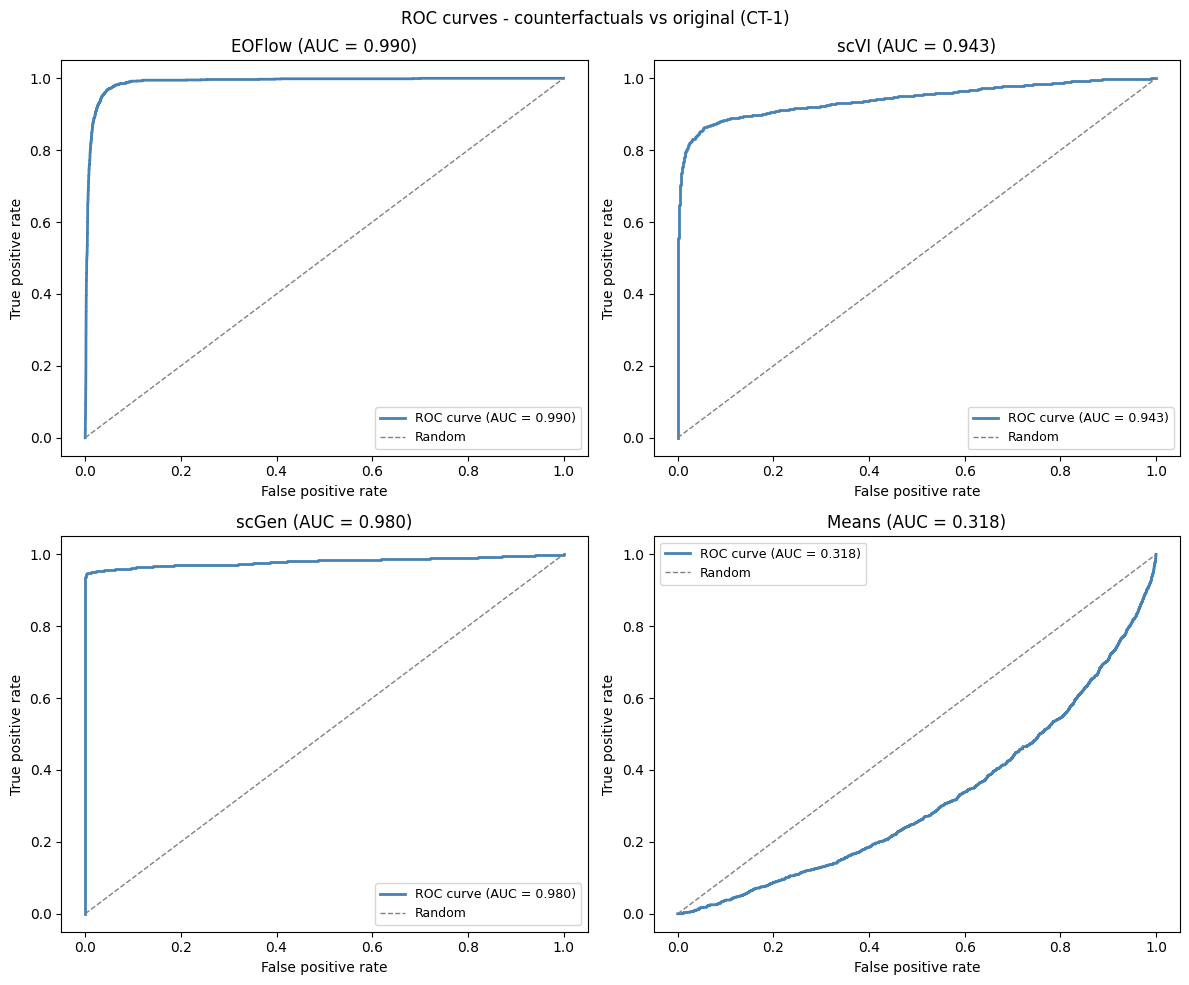

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for m, ax in zip(models, axes.flat):
    _, _, roc_auc = evaluate_cf_roc(m["analyzer"], key=key, cf_fn=m["cf_fn"], num_epochs=10, ax=ax)
    ax.set_title(f"{m['name']} (AUC = {roc_auc:.3f})")
fig.suptitle(f"ROC curves - counterfactuals vs original ({key})")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"roc_comparison_{key}.png"), dpi=300)
plt.show()

### 3.2 MMD

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:30<00:00,  2.75s/it]


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer set

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:30<00:00,  2.77s/it]


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:36<00:00,  3.33s/it]


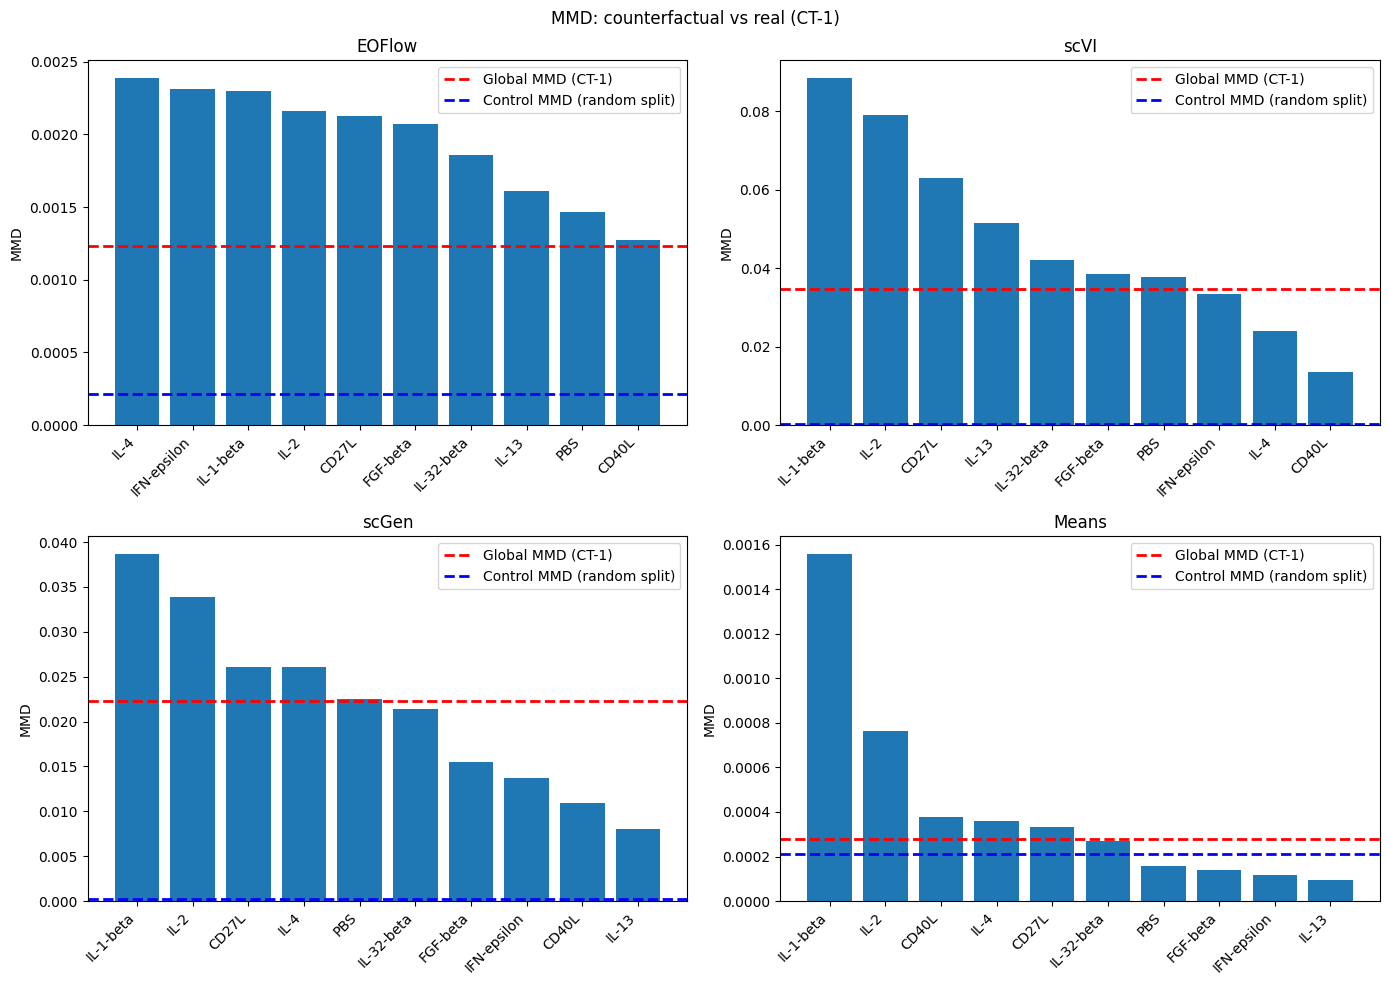

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for m, ax in zip(models, axes.flat):
    analyzer = m["analyzer"]
    ctrl_mmd = ctrl_mmd_dists(analyzer, key=key, log1p_transform=m["log1p_transform"])
    global_mmd, mmd_per_group = mmd_dists(
        analyzer, key=key, sigma=1.0, cf_fn=m["cf_fn"], log1p_transform=False
    )
    plot_mmd_dists(analyzer, ctrl_mmd, global_mmd, mmd_per_group, key=key, ax=ax)
    ax.set_title(m["name"])
fig.suptitle(f"MMD: counterfactual vs real ({key})")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"mmd_comparison_{key}.png"), dpi=300)
plt.show()

### 3.3 Mean Expression

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer set

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     Received view of anndata, making copy.                                                                    


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     Received view of anndata, making copy.                                                                    


...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


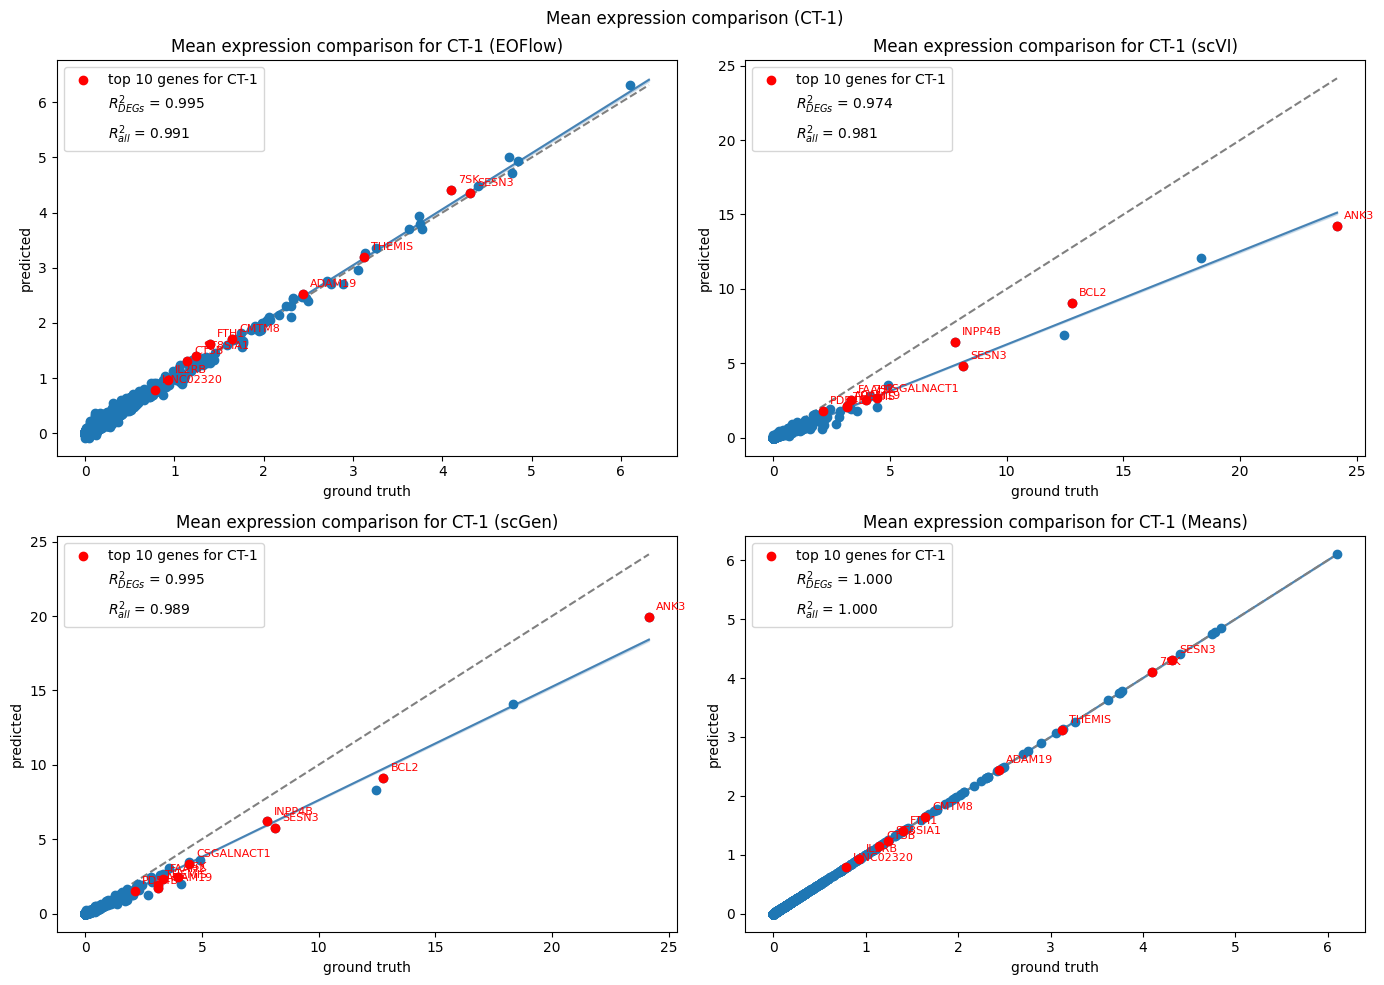

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for m, ax in zip(models, axes.flat):
    plot_mean_expression_comparison(
        m["analyzer"],
        key=key,
        top_n=10,
        cfs_fn=m["cf_fn"],
        log1p_transform=False,
        method=m["name"],
        ax=ax,
    )
fig.suptitle(f"Mean expression comparison ({key})")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"mean_expression_comparison_{key}.png"), dpi=300)
plt.show()

### 3.4 Effect Size

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer set

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     Received view of anndata, making copy.                                                                    


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     Received view of anndata, making copy.                                                                    


...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


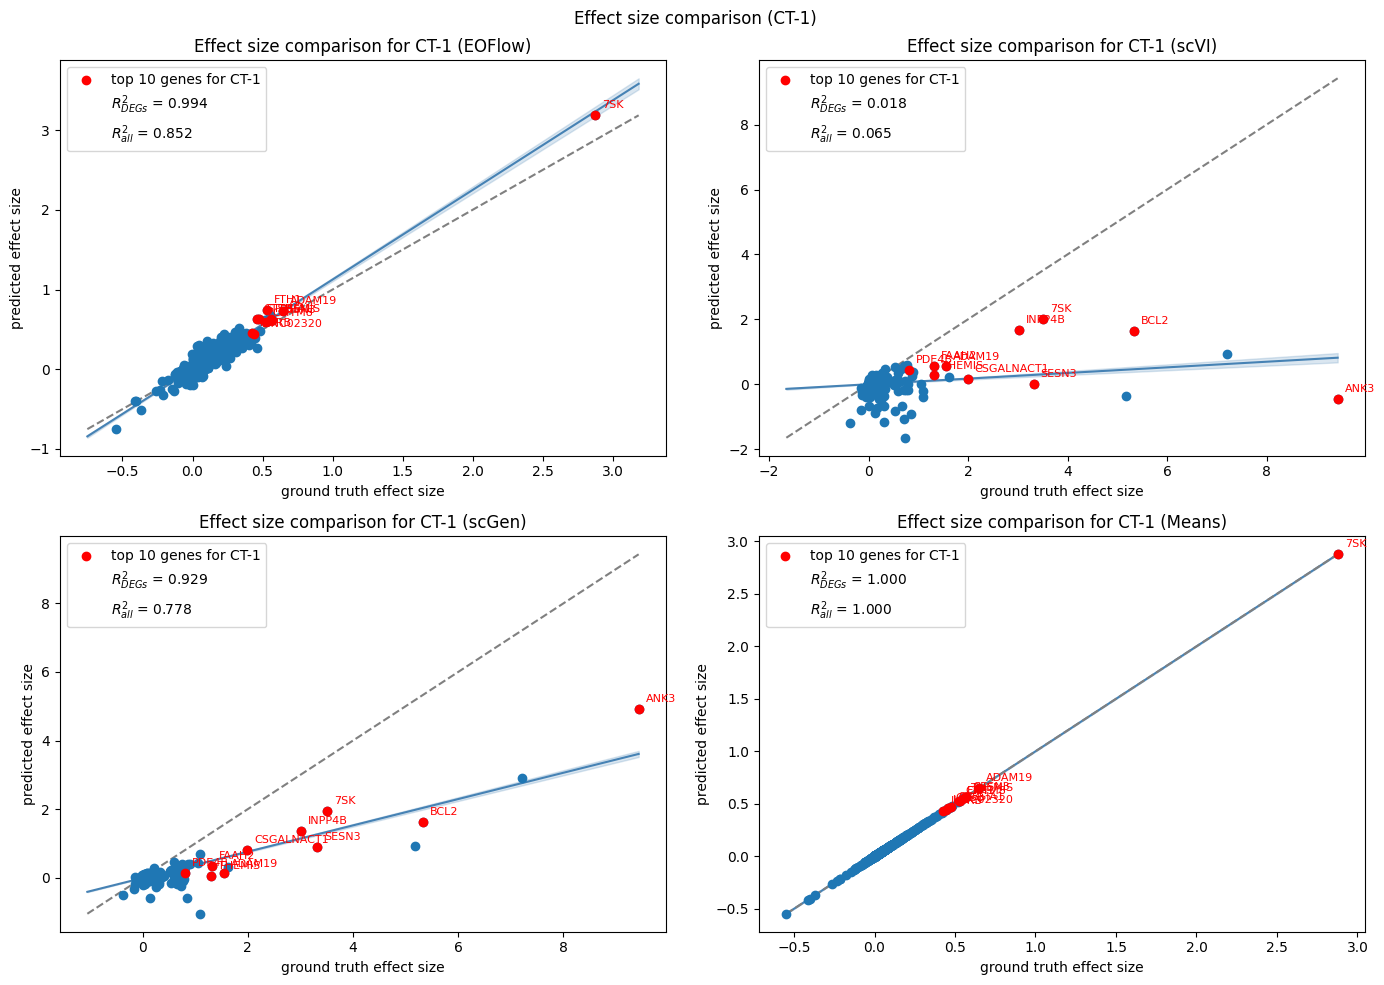

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for m, ax in zip(models, axes.flat):
    plot_effect_size_comparison(
        m["analyzer"],
        key=key,
        top_n=10,
        cfs_fn=m["cf_fn"],
        log1p_transform=False,
        method=m["name"],
        ax=ax,
    )
fig.suptitle(f"Effect size comparison ({key})")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"effect_size_comparison_{key}.png"), dpi=300)
plt.show()

### 3.5 Violin Plots

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer set

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     Received view of anndata, making copy.                                                                    


...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


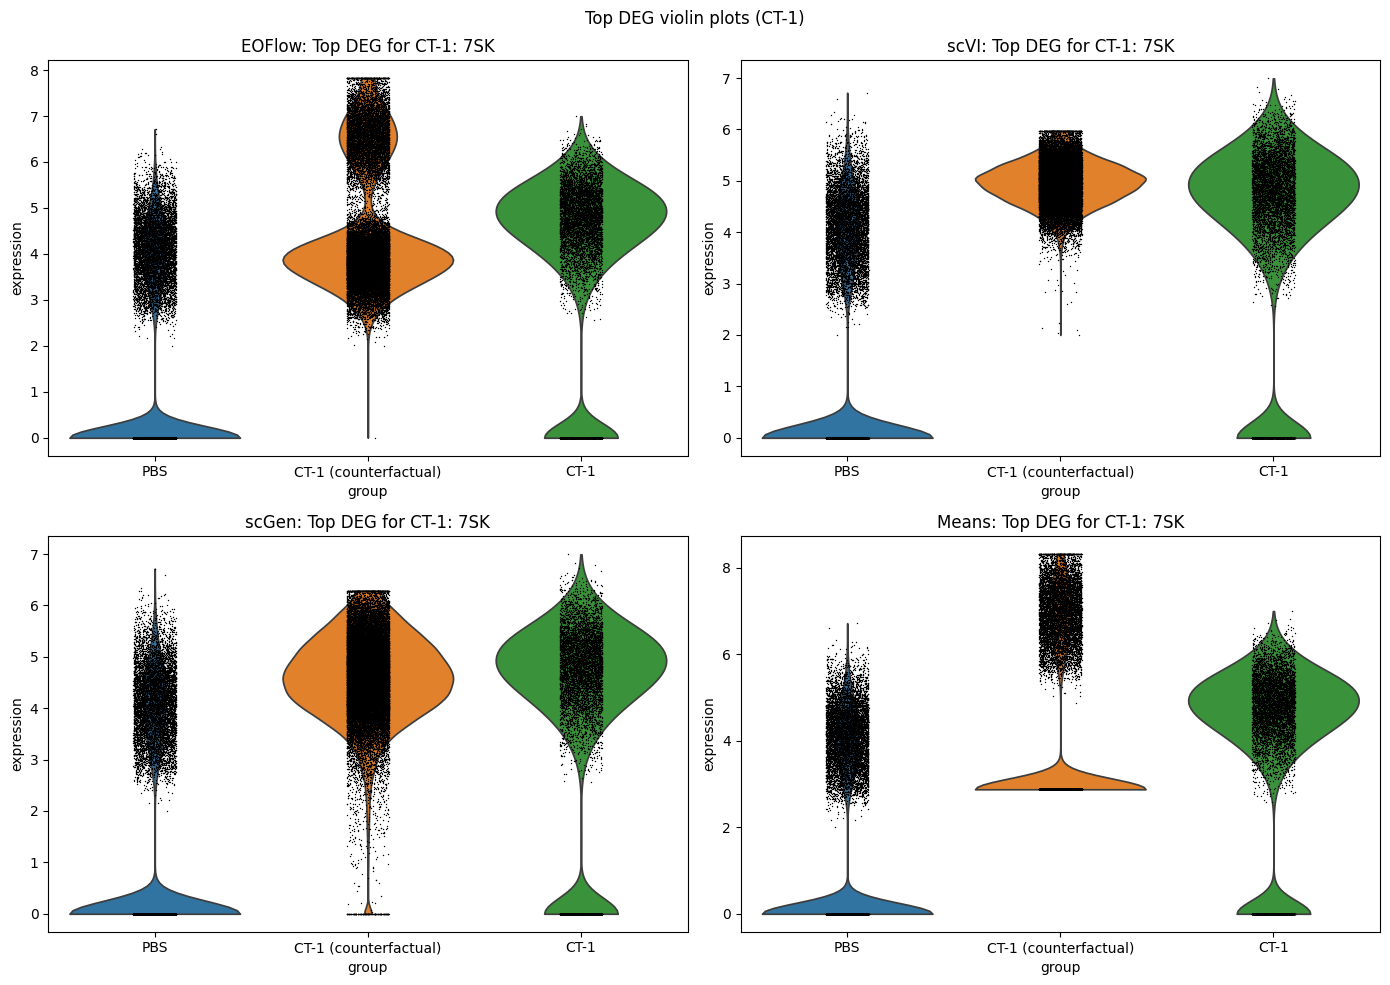

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for m, ax in zip(models, axes.flat):
    plot_top_deg_violin(
        m["analyzer"],
        key=key,
        cfs_fn=m["cf_fn"],
        log1p_transform=m["log1p_transform"],
        ax=ax,
    )
    ax.set_title(f"{m['name']}: {ax.get_title()}")
fig.suptitle(f"Top DEG violin plots ({key})")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"violin_comparison_{key}.png"), dpi=300)
plt.show()